In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)

import pandas as pd
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger

2026-06-20 17:25:14.950988: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-20 17:25:15.050859: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781951115.089412  104922 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781951115.100294  104922 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781951115.175302  104922 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [5]:
# ini sebenarnya level 2 tapi salah nama folder jadi 3
Load_Path = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/dwt/"
ukuran = 64

In [6]:

train_data = np.load(os.path.join(Load_Path, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(Load_Path, "tow_ids_test_dwt.npz"))
validation_data = np.load(os.path.join(Load_Path, "tow_ids_eval_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_val = validation_data["X"]
y_val = validation_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(3289, 64, 64, 3) (3289,)
(1413, 64, 64, 3) (1413,)
(3092, 64, 64, 3) (3092,)


In [7]:
print("Train :", np.unique(y_train))
print("Val   :", np.unique(y_val))
print("Test  :", np.unique(y_test))

Train : [0 1 2 3 4 5]
Val   : [0 1 2 3 4 5]
Test  : [0 1 2 3 4 5]


In [8]:
import pandas as pd

label_names = {
    0: "Normal",
    1: "C_D",
    2: "P_I",
    3: "F_I",
    4: "M_F",
    5: "C_R"
}

for name, label in [
    ("TRAIN", y_train),
    ("VALIDATION", y_val),
    ("TEST", y_test)
]:

    df = (
        pd.Series(label)
        .value_counts()
        .sort_index()
        .rename(index=label_names)
        .to_frame("Jumlah")
    )

    df["Persentase (%)"] = (
        df["Jumlah"] / df["Jumlah"].sum() * 100
    ).round(2)

    print(f"\n{name}")
    print(df)


TRAIN
        Jumlah  Persentase (%)
Normal    1335           40.59
C_D        489           14.87
P_I        530           16.11
F_I        371           11.28
M_F        287            8.73
C_R        277            8.42

VALIDATION
        Jumlah  Persentase (%)
Normal     573           40.55
C_D        210           14.86
P_I        228           16.14
F_I        159           11.25
M_F        123            8.70
C_R        120            8.49

TEST
        Jumlah  Persentase (%)
Normal    1600           51.75
C_D        340           11.00
P_I        299            9.67
F_I        251            8.12
M_F        199            6.44
C_R        403           13.03


In [9]:
print(X_train.dtype)
print(X_val.dtype)
print(X_test.dtype)

print(y_train.dtype)

float32
float32
float32
int64


In [10]:
print(X_train.min(), X_train.max())
print(X_val.min(), X_val.max())
print(X_test.min(), X_test.max())

-0.72264206 4.4806385
-0.71327895 4.0488954
-0.69433486 4.316303


In [11]:
print(np.isnan(X_train).sum())
print(np.isnan(X_val).sum())
print(np.isnan(X_test).sum())

0
0
0


In [12]:
print(np.isinf(X_train).sum())
print(np.isinf(X_val).sum())
print(np.isinf(X_test).sum())

0
0
0


In [13]:
print(X_train[0].shape)

(64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.51983064..3.0274508].


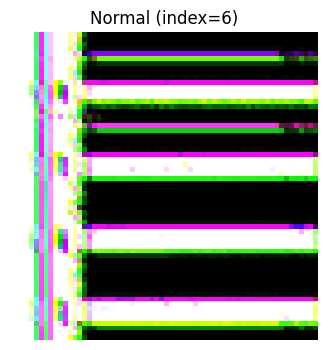

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38540658..3.0274508].


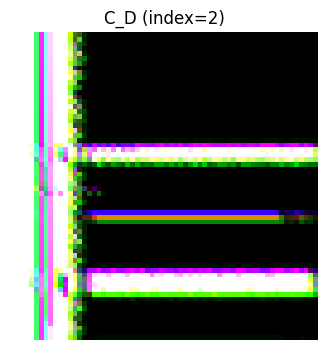

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47247362..3.0196078].


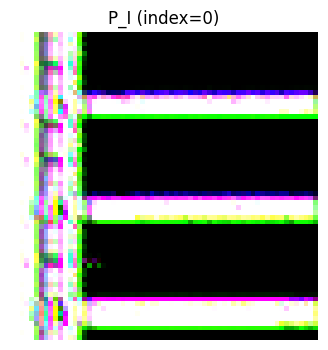

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48989928..3.05098].


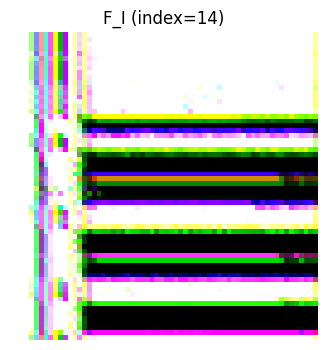

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38557738..3.8749652].


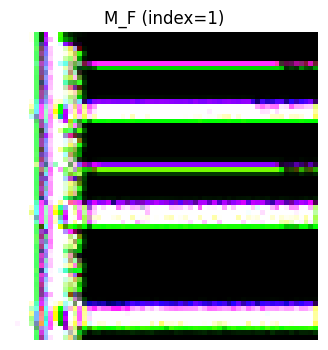

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.53768325..3.270588].


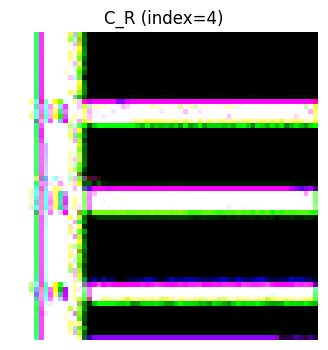

In [16]:
import matplotlib.pyplot as plt

label_names = {
    0: "Normal",
    1: "C_D",
    2: "P_I",
    3: "F_I",
    4: "M_F",
    5: "C_R"
}

for cls in range(6):
    idx = np.where(y_train == cls)[0][0]

    plt.figure(figsize=(4,4))
    plt.imshow(X_train[idx])
    plt.title(f"{label_names[cls]} (index={idx})")
    plt.axis("off")
    plt.show()

In [15]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

for c, w in zip(classes, weights):
    print(c, w)

0 0.41061173533083645
1 1.1209952283571916
2 1.0342767295597484
3 1.4775381850853548
4 1.9099883855981417
5 1.9789410348977137


In [23]:
print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Test label distribution :", np.unique(y_test, return_counts=True))
print("Validation label distribution :", np.unique(y_val, return_counts=True))

print("Min value:", X_train.min())
print("Max value:", X_train.max())


Train label distribution: (array([0, 1, 2, 3, 4, 5]), array([1335,  489,  530,  371,  287,  277]))
Test label distribution : (array([0, 1, 2, 3, 4, 5]), array([1600,  340,  299,  251,  199,  403]))
Validation label distribution : (array([0, 1, 2, 3, 4, 5]), array([573, 210, 228, 159, 123, 120]))
Min value: -0.72264206
Max value: 4.4806385


In [24]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models


def composite_conv(x, filters, kernel_size):
    x = layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.ReLU()(x)

    return x


def SE_block(x, ratio=16):
    channels = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Dense(
        max(channels // ratio, 4),
        activation="relu"
    )(se)

    se = layers.Dense(
        channels,
        activation="sigmoid"
    )(se)

    se = layers.Reshape((1, 1, channels))(se)

    out = layers.Multiply()([x, se])

    return out


def DPDB_block(x, filters, pool=True):
    shortcut = x

    h = composite_conv(x, filters // 2, (1, 3))

    v = composite_conv(x, filters // 2, (3, 1))

    concat = layers.Concatenate()([h, v])

    fusion = composite_conv(concat, filters, (1, 1))

    fusion = SE_block(fusion)

    if pool:
        fusion = layers.MaxPooling2D((2, 2))(fusion)

    shortcut = layers.Conv2D(
        filters,
        (1, 1),
        padding="same",
        use_bias=False
    )(shortcut)

    shortcut = layers.BatchNormalization()(shortcut)

    if pool:
        shortcut = layers.MaxPooling2D((2, 2))(shortcut)

    out = layers.Add()([fusion, shortcut])

    out = layers.ReLU()(out)

    return out


input_layer = layers.Input(shape=(ukuran, ukuran, 3))

x = composite_conv(input_layer, 16, (1, 3))

x = composite_conv(x, 16, (3, 1))

x = DPDB_block(x, 32, pool=True)

x = DPDB_block(x, 64, pool=False)

x = composite_conv(x, 48, (1, 1))

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dropout(0.5)(x)

NUM_CLASSES = 6

output_layer = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(
    inputs=input_layer,
    outputs=output_layer
)

model.compile(

    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-5
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),

    metrics=[

        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │        144 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │        768 │ re_lu_22[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_23 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │        768 │ re_lu_23[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 64, 64,    │        768 │ re_lu_23[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 64, 64,    │          0 │ re_lu_24[0][0],   │
│ (Concatenate)       │ 32)               │            │ re_lu_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │      1,024 │ concatenate_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 25,214 (98.49 KB)

 Trainable params: 24,478 (95.62 KB)

 Non-trainable params: 736 (2.88 KB)

In [26]:
print("Train")
print("Mean :", X_train.mean())
print("Std  :", X_train.std())

print("Validation")
print("Mean :", X_val.mean())
print("Std  :", X_val.std())

print("Test")
print("Mean :", X_test.mean())
print("Std  :", X_test.std())

Train
Mean : 0.70943135
Std  : 0.8582334
Validation
Mean : 0.71364737
Std  : 0.858736
Test
Mean : 0.73378134
Std  : 0.8671197


In [27]:
CONFIG = {
    "image_size": 64,
    "classes": 6,
    "loss": "SparseCategoricalCrossentropy",
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "batch_size": 32,
    "epochs": 100,
}

In [28]:
LABEL_MAP = {
    0: "Normal",
    1: "C_D",
    2: "P_I",
    3: "F_I",
    4: "M_F",
    5: "C_R",
}

In [29]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.debugging.set_log_device_placement(True)

TensorFlow version: 2.19.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [30]:
class TrainingLogger(Callback):

    def on_train_begin(self, logs=None):
        print("\nTraining started")
        print("-"*70)
        print("{:<8} {:<12} {:<12} {:<12} {:<12}".format(
            "Epoch","Loss","Accuracy","Val_Loss","Val_Acc"))
        print("-"*70)

    def on_epoch_end(self, epoch, logs=None):

        print("{:<8} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
            epoch+1,
            logs["loss"],
            logs["accuracy"],
            logs["val_loss"],
            logs["val_accuracy"]
        ))

In [31]:
checkpoint = ModelCheckpoint(
    "best_model_tow_ids_multiclass_img64.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [32]:
print("\nDataset summary")
print("-"*40)
print("Train samples      :", X_train.shape[0])
print("Validation samples :", X_val.shape[0])
print("Test samples       :", X_test.shape[0])
print("Image shape        :", X_train.shape[1:])
print("Number of classes  :", len(np.unique(y_train)))
print("Batch size         :", 32)
print("Epochs             :", 50)
print("-"*40)


Dataset summary
----------------------------------------
Train samples      : 3289
Validation samples : 1413
Test samples       : 3092
Image shape        : (64, 64, 3)
Number of classes  : 6
Batch size         : 32
Epochs             : 50
----------------------------------------


In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[
        checkpoint,
        TrainingLogger()
    ]
)


Training started
----------------------------------------------------------------------
Epoch    Loss         Accuracy     Val_Loss     Val_Acc     
----------------------------------------------------------------------
Epoch 1/50


I0000 00:00:1781953284.339063  108283 service.cc:152] XLA service 0x74e5780029d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781953284.339085  108283 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-06-20 18:01:24.457654: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781953285.170087  108283 cuda_dnn.cc:529] Loaded cuDNN version 91701


 15/103 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1579 - loss: 1.8838

I0000 00:00:1781953293.579931  108283 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.2086 - loss: 1.7929
Epoch 1: val_accuracy improved from None to 0.10050, saving model to best_model_tow_ids_multiclass_img64.keras
1        1.7012       0.2764       1.7458       0.1005      
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.2764 - loss: 1.7012 - val_accuracy: 0.1005 - val_loss: 1.7458
Epoch 2/50
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4585 - loss: 1.5097
Epoch 2: val_accuracy improved from 0.10050 to 0.55768, saving model to best_model_tow_ids_multiclass_img64.keras
2        1.4650       0.4898       1.6214       0.5577      
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4898 - loss: 1.4650 - val_accuracy: 0.5577 - val_loss: 1.6214
Epoch 3/50
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5685 - loss: 1.3506
Epoch 3: val_accuracy improved from 0.55768 to 0.61217, saving model to best_model_tow_ids_multiclass_img64.keras
3        1.3131       0.5819       1.3607       0.6

In [34]:
# =========================
# CELL 1
# =========================

import numpy as np

# probabilitas semua kelas
y_prob = model.predict(X_test)

# prediksi kelas
y_pred = np.argmax(y_prob, axis=1)

# label asli
y_true = y_test

print("Prediction shape :", y_prob.shape)
print("Prediction label :", np.unique(y_pred))

97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
Prediction shape : (3092, 6)
Prediction label : [0 1 2 3 4 5]


In [35]:
# =========================
# CELL 2
# =========================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[1553    0    0   41    0    6]
 [   7  323    0    0    0   10]
 [   1    0  297    0    0    1]
 [   2    0    0  249    0    0]
 [   0    0    0    1  198    0]
 [  16    0    0    2    0  385]]


In [36]:
from sklearn.metrics import classification_report

label_names = [
    "Normal",
    "C_D",
    "P_I",
    "F_I",
    "M_F",
    "C_R"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    digits=4
))

              precision    recall  f1-score   support

      Normal     0.9835    0.9706    0.9770      1600
         C_D     1.0000    0.9500    0.9744       340
         P_I     1.0000    0.9933    0.9966       299
         F_I     0.8498    0.9920    0.9154       251
         M_F     1.0000    0.9950    0.9975       199
         C_R     0.9577    0.9553    0.9565       403

    accuracy                         0.9719      3092
   macro avg     0.9652    0.9760    0.9696      3092
weighted avg     0.9738    0.9719    0.9723      3092



In [37]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)

print(acc)

0.9718628719275549


In [38]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro"
)

print(precision)
print(recall)
print(f1)

0.9651791127543053
0.9760462952106949
0.9695806829334628


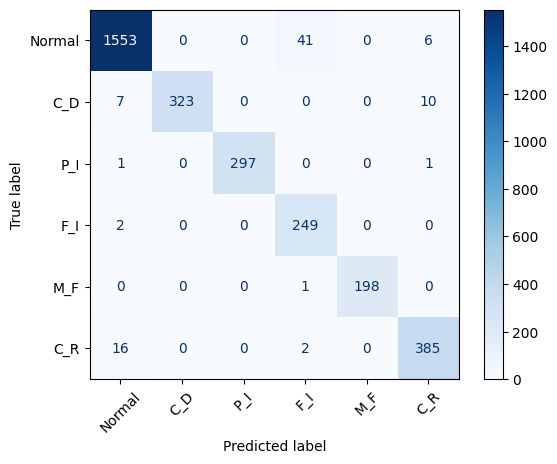

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "C_D",
        "P_I",
        "F_I",
        "M_F",
        "C_R"
    ]
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

In [40]:
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [41]:
import pandas as pd

result = pd.DataFrame({
    "True": y_true,
    "Pred": y_pred
})

result.to_csv("prediction_test.csv", index=False)

In [42]:
np.save("prediction_probability.npy", y_prob)

In [43]:
plt.savefig("confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

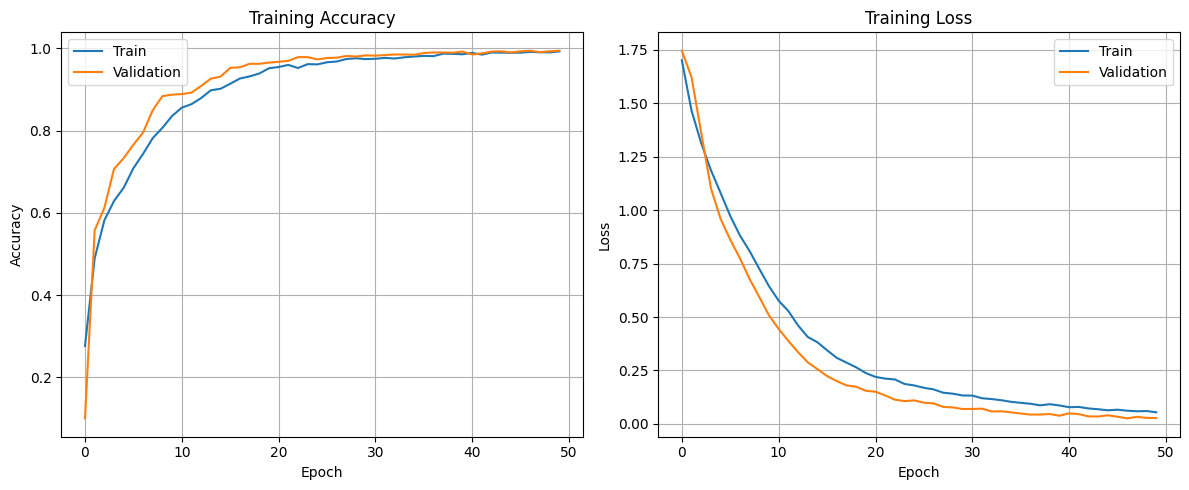

In [44]:
# =========================
# TRAINING CURVE
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# =========================
# PER-CLASS PERFORMANCE
# =========================

import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

label_names = [
    "Normal",
    "C_D",
    "P_I",
    "F_I",
    "M_F",
    "C_R"
]

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0,1,2,3,4,5]
)

metric_df = pd.DataFrame({
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
}, index=label_names)

print(metric_df.round(4))

metric_df.to_csv("per_class_metrics.csv")

        Precision  Recall  F1-score  Support
Normal     0.9835  0.9706    0.9770     1600
C_D        1.0000  0.9500    0.9744      340
P_I        1.0000  0.9933    0.9966      299
F_I        0.8498  0.9920    0.9154      251
M_F        1.0000  0.9950    0.9975      199
C_R        0.9577  0.9553    0.9565      403


In [46]:
# =========================
# MISCLASSIFICATION
# =========================

import pandas as pd

label_names = {
    0:"Normal",
    1:"C_D",
    2:"P_I",
    3:"F_I",
    4:"M_F",
    5:"C_R"
}

error_df = pd.DataFrame({
    "True": y_true,
    "Pred": y_pred
})

error_df = error_df[
    error_df["True"] != error_df["Pred"]
].copy()

error_df["True"] = error_df["True"].map(label_names)
error_df["Pred"] = error_df["Pred"].map(label_names)

print(error_df.head())

print("\nJumlah salah klasifikasi :", len(error_df))

print("\nKesalahan terbanyak")
print(
    error_df
    .groupby(["True","Pred"])
    .size()
    .sort_values(ascending=False)
)

     True Pred
0  Normal  F_I
1  Normal  F_I
2  Normal  F_I
3  Normal  F_I
4  Normal  F_I

Jumlah salah klasifikasi : 87

Kesalahan terbanyak
True    Pred  
Normal  F_I       41
C_R     Normal    16
C_D     C_R       10
        Normal     7
Normal  C_R        6
C_R     F_I        2
F_I     Normal     2
M_F     F_I        1
P_I     C_R        1
        Normal     1
dtype: int64


In [47]:
idx = np.where((y_true==0)&(y_pred==3))[0]

In [48]:
print(idx)

[   0    1    2    3    4  239  250  261  267  272  278  284  301  329
  335  346  352  358  391  397  409  414  420  431  437  442  448  454
  460  471  494  523 1567 1867 1873 1878 2105 2160 2221 2271 2304]


In [49]:
print(np.diff(idx))

[   1    1    1    1  235   11   11    6    5    6    6   17   28    6
   11    6    6   33    6   12    5    6   11    6    5    6    6    6
   11   23   29 1044  300    6    5  227   55   61   50   33]


In [50]:
WINDOW_SIZE = 64

packet_start = idx * WINDOW_SIZE
packet_end   = packet_start + WINDOW_SIZE - 1

In [51]:
window_df = pd.DataFrame({
    "window": idx,
    "packet_start": packet_start,
    "packet_end": packet_end
})

print(window_df.head(10))

   window  packet_start  packet_end
0       0             0          63
1       1            64         127
2       2           128         191
3       3           192         255
4       4           256         319
5     239         15296       15359
6     250         16000       16063
7     261         16704       16767
8     267         17088       17151
9     272         17408       17471


In [52]:
correct_idx = np.where((y_true==0)&(y_pred==0))[0][:5]

wrong_idx = np.where((y_true==0)&(y_pred==3))[0][:5]

In [53]:
idx_cr = np.where((y_true==5)&(y_pred!=5))[0]

print(idx_cr)

[1193 1253 1259 1300 1303 1316 1389 1419 1445 1454 1489 1505 1506 1521
 1529 1537 1550 1552]


In [54]:
packet_start = idx_cr * 64
packet_end = packet_start + 63

In [55]:
idx_correct = np.where((y_true==5)&(y_pred==5))[0]

In [56]:
print(len(idx_correct))
print(len(idx_cr))

385
18


In [57]:
import os
import numpy as np

Loader = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/"
SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3multiclass/norm/"

# Buat folder output jika belum ada
os.makedirs(SAVE_DIR, exist_ok=True)

train_path = os.path.join(Loader, "tow_ids_train_windows.npz")
eval_path = os.path.join(Loader, "tow_ids_eval_windows.npz")


# Load data
train_data = np.load(train_path)
eval_data = np.load(eval_path)

x_seq_train = train_data["X"]
y_seq_train = train_data["y"]

x_seq_eval = eval_data["X"]
y_seq_eval = eval_data["y"]
test_path  = os.path.join(Loader, "tow_ids_test_windows.npz")
# load
test_data  = np.load(test_path)

x_seq_test  = test_data["X"]
y_seq_test  = test_data["y"]

In [58]:
print("Train :", x_seq_train.shape, y_seq_train.shape)
print("Eval  :", x_seq_eval.shape, y_seq_eval.shape)
print("Test  :", x_seq_test.shape, y_seq_test.shape)

print("\nLabel test :", np.unique(y_seq_test))

Train : (3289, 256, 256) (3289,)
Eval  : (1413, 256, 256) (1413,)
Test  : (3092, 256, 256) (3092,)

Label test : [0 1 2 3 4 5]


In [59]:
print(x_seq_test.dtype)
print(x_seq_test.min(), x_seq_test.max())

uint8
0 255


In [60]:
# Replay benar
idx_cr_correct = np.where(
    (y_test == 5) &
    (y_pred == 5)
)[0]

# Replay salah
idx_cr_wrong = np.where(
    (y_test == 5) &
    (y_pred != 5)
)[0]

# Normal benar
idx_normal = np.where(
    (y_test == 0) &
    (y_pred == 0)
)[0]

print(len(idx_cr_correct))
print(len(idx_cr_wrong))
print(len(idx_normal))

385
18
1553


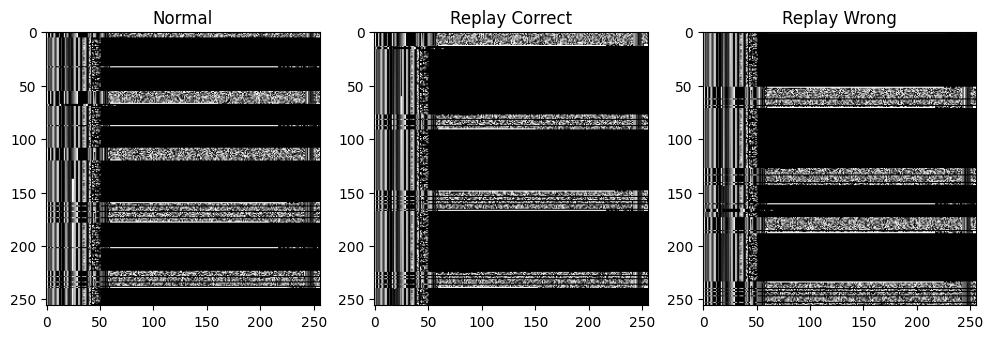

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(
    x_seq_test[idx_normal[0]],
    cmap="gray"
)

ax[0].set_title("Normal")

ax[1].imshow(
    x_seq_test[idx_cr_correct[0]],
    cmap="gray"
)

ax[1].set_title("Replay Correct")

ax[2].imshow(
    x_seq_test[idx_cr_wrong[0]],
    cmap="gray"
)

ax[2].set_title("Replay Wrong")

plt.show()

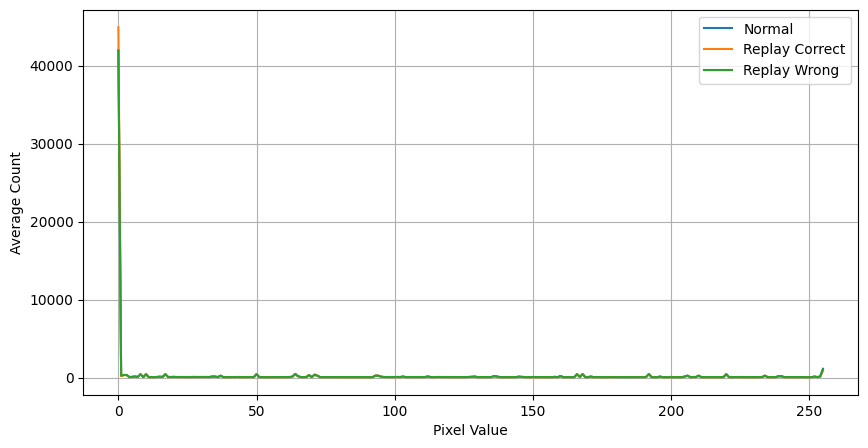

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def mean_histogram(images):
    hist = np.zeros(256)

    for img in images:
        h, _ = np.histogram(
            img.flatten(),
            bins=256,
            range=(0,255)
        )
        hist += h

    hist /= len(images)

    return hist

hist_normal = mean_histogram(x_seq_test[idx_normal])
hist_correct = mean_histogram(x_seq_test[idx_cr_correct])
hist_wrong = mean_histogram(x_seq_test[idx_cr_wrong])

plt.figure(figsize=(10,5))

plt.plot(hist_normal, label="Normal")
plt.plot(hist_correct, label="Replay Correct")
plt.plot(hist_wrong, label="Replay Wrong")

plt.xlabel("Pixel Value")
plt.ylabel("Average Count")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
import numpy as np

def shannon_entropy(img):

    # hitung frekuensi byte 0-255
    hist = np.bincount(
        img.flatten(),
        minlength=256
    ).astype(np.float64)

    # ubah menjadi probabilitas
    prob = hist / hist.sum()

    # buang probabilitas nol
    prob = prob[prob > 0]

    # Shannon entropy
    entropy = -np.sum(prob * np.log2(prob))

    return entropy

In [64]:
entropy_normal = [
    shannon_entropy(x_seq_test[i])
    for i in idx_normal
]

entropy_correct = [
    shannon_entropy(x_seq_test[i])
    for i in idx_cr_correct
]

entropy_wrong = [
    shannon_entropy(x_seq_test[i])
    for i in idx_cr_wrong
]

In [65]:
import pandas as pd

df_entropy = pd.DataFrame({
    "Normal": pd.Series(entropy_normal),
    "Replay Correct": pd.Series(entropy_correct),
    "Replay Wrong": pd.Series(entropy_wrong)
})

print(df_entropy.describe().round(4))

          Normal  Replay Correct  Replay Wrong
count  1553.0000        385.0000       18.0000
mean      3.6309          3.2090        3.6322
std       0.3330          0.2830        0.2466
min       2.6582          2.4336        3.2236
25%       3.4094          3.0241        3.4819
50%       3.5887          3.1737        3.6072
75%       3.8131          3.3792        3.8422
max       4.9797          4.0330        4.0088


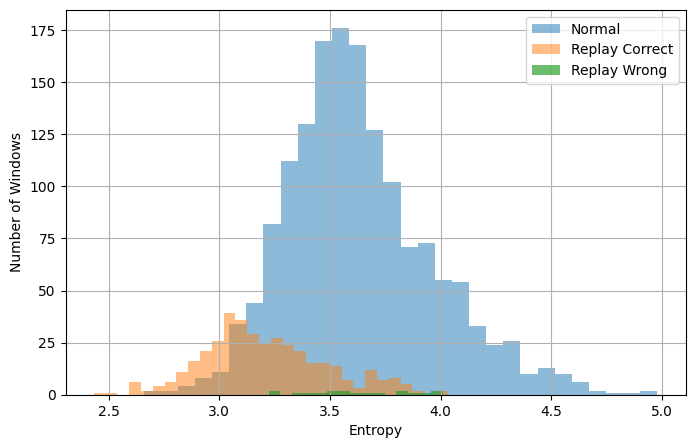

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    entropy_normal,
    bins=30,
    alpha=0.5,
    label="Normal"
)

plt.hist(
    entropy_correct,
    bins=30,
    alpha=0.5,
    label="Replay Correct"
)

plt.hist(
    entropy_wrong,
    bins=15,
    alpha=0.7,
    label="Replay Wrong"
)

plt.xlabel("Entropy")
plt.ylabel("Number of Windows")
plt.legend()

plt.grid(True)

plt.show()

In [67]:
def zero_ratio(img):
    return np.mean(img == 0)

In [68]:
zero_normal = [
    zero_ratio(x_seq_test[i])
    for i in idx_normal
]

zero_correct = [
    zero_ratio(x_seq_test[i])
    for i in idx_cr_correct
]

zero_wrong = [
    zero_ratio(x_seq_test[i])
    for i in idx_cr_wrong
]

In [69]:
import pandas as pd

df = pd.DataFrame({
    "Normal": pd.Series(zero_normal),
    "Replay Correct": pd.Series(zero_correct),
    "Replay Wrong": pd.Series(zero_wrong)
})

print(df.describe())

            Normal  Replay Correct  Replay Wrong
count  1553.000000      385.000000     18.000000
mean      0.639701        0.685561      0.640412
std       0.035866        0.029252      0.026234
min       0.486816        0.595978      0.599762
25%       0.620575        0.668411      0.617489
50%       0.644257        0.689056      0.642616
75%       0.663803        0.705841      0.657253
max       0.738098        0.763443      0.683212


In [74]:
idx_cr_wrong = np.where((y_seq_test == 5) & (y_pred != 5))[0]

print("Jumlah Replay yang gagal :", len(idx_cr_wrong))
print(idx_cr_wrong)

Jumlah Replay yang gagal : 18
[1193 1253 1259 1300 1303 1316 1389 1419 1445 1454 1489 1505 1506 1521
 1529 1537 1550 1552]


In [75]:
WINDOW_SIZE = 256

label_names = {
    0: "Normal",
    1: "C_D",
    2: "P_I",
    3: "F_I",
    4: "M_F",
    5: "C_R"
}

for w in idx_cr_wrong:

    start = w * WINDOW_SIZE
    end = start + WINDOW_SIZE

    labels = labels_test2[start:end]

    print("="*60)
    print(f"Window : {w}")
    print(f"Packet : {start} - {end-1}")

    print(pd.Series(labels).value_counts())

Window : 1193
Packet : 305408 - 305663
Normal    186
C_R        70
Name: count, dtype: int64
Window : 1253
Packet : 320768 - 321023
Normal    191
C_R        65
Name: count, dtype: int64
Window : 1259
Packet : 322304 - 322559
Normal    182
C_R        74
Name: count, dtype: int64
Window : 1300
Packet : 332800 - 333055
Normal    187
C_R        69
Name: count, dtype: int64
Window : 1303
Packet : 333568 - 333823
Normal    183
C_R        73
Name: count, dtype: int64
Window : 1316
Packet : 336896 - 337151
Normal    187
C_R        69
Name: count, dtype: int64
Window : 1389
Packet : 355584 - 355839
Normal    180
C_R        76
Name: count, dtype: int64
Window : 1419
Packet : 363264 - 363519
Normal    178
C_R        78
Name: count, dtype: int64
Window : 1445
Packet : 369920 - 370175
Normal    193
C_R        63
Name: count, dtype: int64
Window : 1454
Packet : 372224 - 372479
Normal    176
C_R        80
Name: count, dtype: int64
Window : 1489
Packet : 381184 - 381439
Normal    191
C_R        65
Nam

In [76]:
summary = []

for w in idx_cr_wrong:

    start = w * WINDOW_SIZE
    end = start + WINDOW_SIZE

    vc = pd.Series(labels_test2[start:end]).value_counts()

    summary.append({
        "window": w,
        "Normal": vc.get("Normal", 0),
        "C_R": vc.get("C_R", 0),
        "C_D": vc.get("C_D", 0),
        "P_I": vc.get("P_I", 0),
        "F_I": vc.get("F_I", 0),
        "M_F": vc.get("M_F", 0),
    })

summary_df = pd.DataFrame(summary)

summary_df

,window,Normal,C_R,C_D,P_I,F_I,M_F
0,1193,186,70,0,0,0,0
1,1253,191,65,0,0,0,0
2,1259,182,74,0,0,0,0
3,1300,187,69,0,0,0,0
4,1303,183,73,0,0,0,0
5,1316,187,69,0,0,0,0
6,1389,180,76,0,0,0,0
7,1419,178,78,0,0,0,0
8,1445,193,63,0,0,0,0
9,1454,176,80,0,0,0,0


In [77]:
label_names = [
    "Normal",
    "C_D",
    "P_I",
    "F_I",
    "M_F",
    "C_R"
]

idx_correct = np.where((y_true == 5) & (y_pred == 5))[0]

print("Jumlah Replay yang benar :", len(idx_correct))

rows = []

for win in idx_correct:

    packet_start = win * 256
    packet_end   = packet_start + 256

    labels = labels_test2[packet_start:packet_end]

    counts = pd.Series(labels).value_counts()

    row = {"window": win}

    for lbl in label_names:
        row[lbl] = counts.get(lbl, 0)

    rows.append(row)

df_correct = pd.DataFrame(rows)

display(df_correct.head())

print()
print(df_correct.describe())

Jumlah Replay yang benar : 385


,window,Normal,C_D,P_I,F_I,M_F,C_R
0,1161,191,0,0,0,0,65
1,1162,178,0,0,0,0,78
2,1163,185,0,0,0,0,71
3,1164,183,0,0,0,0,73
4,1165,182,0,0,0,0,74



            window      Normal    C_D    P_I    F_I    M_F         C_R
count   385.000000  385.000000  385.0  385.0  385.0  385.0  385.000000
mean   1359.392208  181.742857    0.0    0.0    0.0    0.0   74.257143
std     115.911332    5.000923    0.0    0.0    0.0    0.0    5.000923
min    1161.000000  162.000000    0.0    0.0    0.0    0.0   57.000000
25%    1260.000000  179.000000    0.0    0.0    0.0    0.0   71.000000
50%    1359.000000  181.000000    0.0    0.0    0.0    0.0   75.000000
75%    1459.000000  185.000000    0.0    0.0    0.0    0.0   77.000000
max    1563.000000  199.000000    0.0    0.0    0.0    0.0   94.000000


In [79]:
print("Replay Correct")
display(df_correct.describe())

print()

print("Replay Wrong")
display(summary_df.describe())

Replay Correct


,window,Normal,C_D,P_I,F_I,M_F,C_R
count,385.000000,385.000000,385.0,385.0,385.0,385.0,385.000000
mean,1359.392208,181.742857,0.0,0.0,0.0,0.0,74.257143
std,115.911332,5.000923,0.0,0.0,0.0,0.0,5.000923
min,1161.000000,162.000000,0.0,0.0,0.0,0.0,57.000000
25%,1260.000000,179.000000,0.0,0.0,0.0,0.0,71.000000
50%,1359.000000,181.000000,0.0,0.0,0.0,0.0,75.000000
75%,1459.000000,185.000000,0.0,0.0,0.0,0.0,77.000000
max,1563.000000,199.000000,0.0,0.0,0.0,0.0,94.000000



Replay Wrong


,window,Normal,C_R,C_D,P_I,F_I,M_F
count,18.000000,18.000000,18.000000,18.0,18.0,18.0,18.0
mean,1417.777778,186.111111,69.888889,0.0,0.0,0.0,0.0
std,117.916998,5.758767,5.758767,0.0,0.0,0.0,0.0
min,1193.000000,176.000000,62.000000,0.0,0.0,0.0,0.0
25%,1306.250000,182.250000,65.000000,0.0,0.0,0.0,0.0
50%,1449.500000,187.000000,69.000000,0.0,0.0,0.0,0.0
75%,1517.250000,191.000000,73.750000,0.0,0.0,0.0,0.0
max,1552.000000,194.000000,80.000000,0.0,0.0,0.0,0.0


In [80]:
WINDOW_SIZE = 256

wrong_window = 1454
correct_window = idx_correct[0]   # atau ganti manual

wrong_labels = labels_test2[
    wrong_window*WINDOW_SIZE :
    (wrong_window+1)*WINDOW_SIZE
]

correct_labels = labels_test2[
    correct_window*WINDOW_SIZE :
    (correct_window+1)*WINDOW_SIZE
]

In [ ]:
mapping = {
    "Normal":"N",
    "C_D":"D",
    "P_I":"P",
    "F_I":"F",
    "M_F":"M",
    "C_R":"R"
}

wrong_symbol = np.array([mapping[x] for x in wrong_labels])
correct_symbol = np.array([mapping[x] for x in correct_labels])

In [82]:
print("Replay Correct\n")

for row in correct_symbol.reshape(16,16):
    print(" ".join(row))

print("\n")

print("Replay Wrong\n")

for row in wrong_symbol.reshape(16,16):
    print(" ".join(row))

Replay Correct

N N N N N N N N N N N N N N N N
N N N N N N N N N N N N N N N N
N N N N N N N N N N N N N R N R
N R N N R N N N R N N R N N R N
R N N N R R N R N R N N N R N N
N N N N N N N N N N N N R N N R
N N R N N R N R N R N N N R R N
R N N R N N N R N R N R N N R N
N R N N R N N R N N R N N R N R
N R R N N N N N N N N N N N R N
N N N N N N N N R N N R N N R N
N R N R N R N N R N R N R N N N
R N N R N R N R N N R N N R N N
R N N R N N R N N R N R N R N R
N N N N N N N R N N N N N N N N
N N R N R N N R N N R N R R N N


Replay Wrong

R N N R N N R N N R N N N N N N
N N N N N N N N R N N R N N R R
N N R N R R N R N R N N R N N R
N N N R N N N R N N R N R N N R
N N R N N R N N R N N N N N N N
N N N N N R N R R N N R N R N N
R N N R N N R N N R N N R R N N
N R R R N R N R N N R N N N N N
N N N R N N N R N N R N N N N N
N N R N N N N N N N N N R N N R
N R N N R N R R N R R N N R N N
R N N R N N R N N R N N N R N N
R N R N N R R N R R N R N N R N
N R N N R N N N N N N N N N N N
R N N N 

In [83]:
wrong_binary = (wrong_labels == "C_R").astype(int)
correct_binary = (correct_labels == "C_R").astype(int)

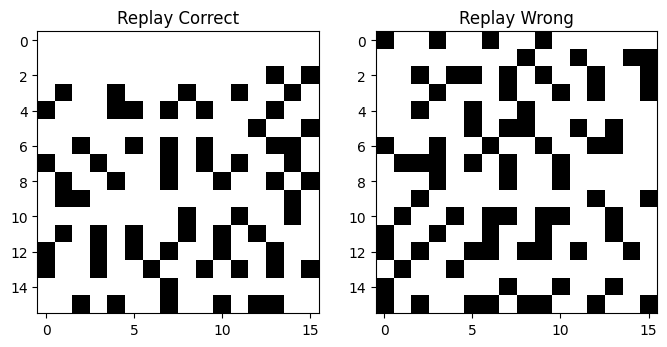

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(8,4))

ax[0].imshow(correct_binary.reshape(16,16),
             cmap="Greys",
             interpolation="nearest")

ax[0].set_title("Replay Correct")

ax[1].imshow(wrong_binary.reshape(16,16),
             cmap="Greys",
             interpolation="nearest")

ax[1].set_title("Replay Wrong")

plt.show()

In [85]:
print("1453 :", y_seq_test[1453], y_pred[1453])
print("1454 :", y_seq_test[1454], y_pred[1454])

1453 : 5 5
1454 : 5 0


In [86]:
WINDOW = 256

start_correct = 1453 * WINDOW
end_correct   = start_correct + WINDOW

start_wrong = 1454 * WINDOW
end_wrong   = start_wrong + WINDOW

In [87]:
print(pd.Series(labels_test2[start_correct:end_correct]).value_counts())

print()

print(pd.Series(labels_test2[start_wrong:end_wrong]).value_counts())

Normal    174
C_R        82
Name: count, dtype: int64

Normal    176
C_R        80
Name: count, dtype: int64


In [88]:
correct = labels_test2[start_correct:end_correct]
wrong   = labels_test2[start_wrong:end_wrong]

correct_pos = np.where(correct == "C_R")[0]
wrong_pos   = np.where(wrong == "C_R")[0]

print(correct_pos)
print()
print(wrong_pos)

[  2   6   9  13  17  21  23  24  26  27  31  34  37  40  43  47  49  52
  54  55  64  68  72  75  79  83  87  90  92  96  97  99 100 103 106 110
 113 116 120 122 124 127 130 140 143 149 152 155 158 162 165 168 171 174
 175 177 179 182 185 188 191 194 198 199 202 204 213 218 220 223 225 229
 232 234 237 240 243 247 250 251 253 254]

[  0   3   6   9  24  27  30  31  34  36  37  39  41  44  47  51  55  58
  60  63  66  69  72  85  87  88  91  93  96  99 102 105 108 109 113 114
 115 117 119 122 131 135 138 146 156 159 161 164 166 167 169 170 173 176
 179 182 185 189 192 194 197 198 200 201 203 206 209 212 224 231 234 237
 240 242 245 246 248 249 252 255]


In [92]:
mapping = {
    "Normal": "N",
    "C_D": "D",
    "P_I": "P",
    "F_I": "F",
    "M_F": "M",
    "C_R": "R"
}

correct_symbol = np.array([mapping[x] for x in correct])
wrong_symbol   = np.array([mapping[x] for x in wrong])

print("Replay Correct\n")

for row in correct_symbol.reshape(16,16):
    print(" ".join(row))

print("\nReplay Wrong\n")

for row in wrong_symbol.reshape(16,16):
    print(" ".join(row))

Replay Correct

N N R N N N R N N R N N N R N N
N R N N N R N R R N R R N N N R
N N R N N R N N R N N R N N N R
N R N N R N R R N N N N N N N N
R N N N R N N N R N N R N N N R
N N N R N N N R N N R N R N N N
R R N R R N N R N N R N N N R N
N R N N R N N N R N R N R N N R
N N R N N N N N N N N N R N N R
N N N N N R N N R N N R N N R N
N N R N N R N N R N N R N N R R
N R N R N N R N N R N N R N N R
N N R N N N R R N N R N R N N N
N N N N N R N N N N R N R N N R
N R N N N R N N R N R N N R N N
R N N R N N N R N N R R N R R N

Replay Wrong

R N N R N N R N N R N N N N N N
N N N N N N N N R N N R N N R R
N N R N R R N R N R N N R N N R
N N N R N N N R N N R N R N N R
N N R N N R N N R N N N N N N N
N N N N N R N R R N N R N R N N
R N N R N N R N N R N N R R N N
N R R R N R N R N N R N N N N N
N N N R N N N R N N R N N N N N
N N R N N N N N N N N N R N N R
N R N N R N R R N R R N N R N N
R N N R N N R N N R N N N R N N
R N R N N R R N R R N R N N R N
N R N N R N N N N N N N N N N N
R N N N N

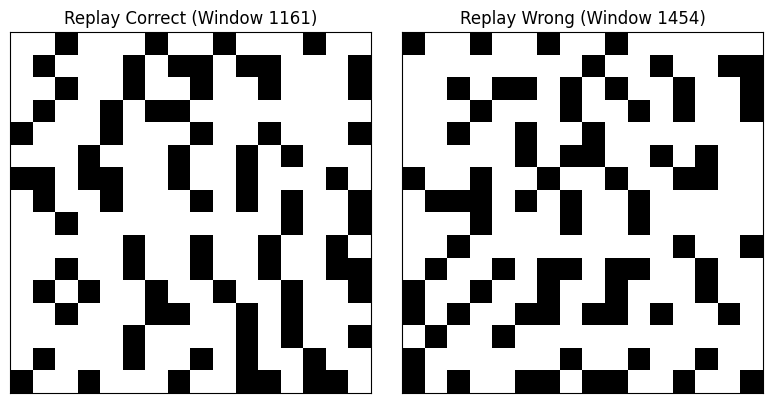

In [93]:
import matplotlib.pyplot as plt

correct_binary = (correct == "C_R").astype(int)
wrong_binary   = (wrong == "C_R").astype(int)

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(
    correct_binary.reshape(16,16),
    cmap="Greys",
    interpolation="nearest"
)
ax[0].set_title(f"Replay Correct (Window {correct_window})")

ax[1].imshow(
    wrong_binary.reshape(16,16),
    cmap="Greys",
    interpolation="nearest"
)
ax[1].set_title(f"Replay Wrong (Window {wrong_window})")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout()
plt.show()

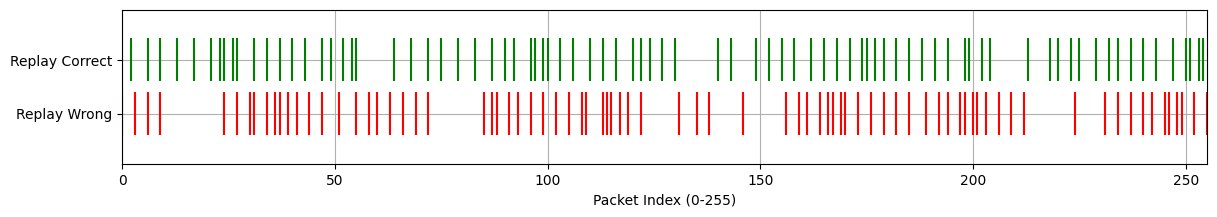

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,2))

plt.eventplot(
    [correct_pos, wrong_pos],
    colors=["green","red"],
    lineoffsets=[2,1],
    linelengths=0.8
)

plt.yticks([2,1], ["Replay Correct","Replay Wrong"])
plt.xlabel("Packet Index (0-255)")
plt.xlim(0,255)

plt.grid(True)

plt.show()

In [94]:
correct_window = 1161
wrong_window = 1454

In [95]:
WINDOW = 256

start_correct = correct_window * WINDOW
end_correct   = start_correct + WINDOW

start_wrong = wrong_window * WINDOW
end_wrong   = start_wrong + WINDOW

correct_labels = labels_test2[start_correct:end_correct]
wrong_labels   = labels_test2[start_wrong:end_wrong]

correct_idx = np.where(correct_labels == "C_R")[0]
wrong_idx   = np.where(wrong_labels == "C_R")[0]

In [96]:
correct_packet_number = start_correct + correct_idx
wrong_packet_number   = start_wrong + wrong_idx

print(correct_packet_number[:20])
print()
print(wrong_packet_number[:20])

[297261 297263 297265 297268 297272 297275 297278 297280 297284 297285
 297287 297289 297293 297308 297311 297314 297317 297319 297321 297325]

[372224 372227 372230 372233 372248 372251 372254 372255 372258 372260
 372261 372263 372265 372268 372271 372275 372279 372282 372284 372287]


In [97]:
print("Replay Correct")
print(correct_packet_number[:5])

print()

print("Replay Wrong")
print(wrong_packet_number[:5])

Replay Correct
[297261 297263 297265 297268 297272]

Replay Wrong
[372224 372227 372230 372233 372248]


In [98]:
import pandas as pd

# Replay Correct
correct_df = pd.DataFrame({
    "Packet_in_Window": correct_idx,
    "Packet_Number": correct_packet_number,
    "Label": correct_labels[correct_idx]
})

print("Replay Correct")
print(correct_df.head(20))


print("\n")

# Replay Wrong
wrong_df = pd.DataFrame({
    "Packet_in_Window": wrong_idx,
    "Packet_Number": wrong_packet_number,
    "Label": wrong_labels[wrong_idx]
})

print("Replay Wrong")
print(wrong_df.head(20))

Replay Correct
    Packet_in_Window  Packet_Number Label
0                 45         297261   C_R
1                 47         297263   C_R
2                 49         297265   C_R
3                 52         297268   C_R
4                 56         297272   C_R
5                 59         297275   C_R
6                 62         297278   C_R
7                 64         297280   C_R
8                 68         297284   C_R
9                 69         297285   C_R
10                71         297287   C_R
11                73         297289   C_R
12                77         297293   C_R
13                92         297308   C_R
14                95         297311   C_R
15                98         297314   C_R
16               101         297317   C_R
17               103         297319   C_R
18               105         297321   C_R
19               109         297325   C_R


Replay Wrong
    Packet_in_Window  Packet_Number Label
0                  0         372224   C_R
1   

In [99]:
import pandas as pd
import numpy as np

# ==========================
# Replay Correct (256 paket)
# ==========================
correct_df = pd.DataFrame({
    "Packet_in_Window": np.arange(WINDOW),
    "Packet_Number": np.arange(start_correct, end_correct),
    "Label": correct_labels
})

print("Replay Correct")
print(correct_df)


print("\n" + "="*80 + "\n")

# ==========================
# Replay Wrong (256 paket)
# ==========================
wrong_df = pd.DataFrame({
    "Packet_in_Window": np.arange(WINDOW),
    "Packet_Number": np.arange(start_wrong, end_wrong),
    "Label": wrong_labels
})

print("Replay Wrong")
print(wrong_df)

Replay Correct
     Packet_in_Window  Packet_Number   Label
0                   0         297216  Normal
1                   1         297217  Normal
2                   2         297218  Normal
3                   3         297219  Normal
4                   4         297220  Normal
..                ...            ...     ...
251               251         297467  Normal
252               252         297468     C_R
253               253         297469     C_R
254               254         297470  Normal
255               255         297471  Normal

[256 rows x 3 columns]


Replay Wrong
     Packet_in_Window  Packet_Number   Label
0                   0         372224     C_R
1                   1         372225  Normal
2                   2         372226  Normal
3                   3         372227     C_R
4                   4         372228  Normal
..                ...            ...     ...
251               251         372475  Normal
252               252         372476     C_R
2

In [100]:
test_data  = np.load(os.path.join(Load_Path, "tow_ids_test_dwt.npz"))
X_test  = test_data["X"]
y_test  = test_data["y"]

In [101]:
print(X_test.shape)
print(y_test.shape)

print("Replay Correct :", X_test[1453].shape)
print("Replay Wrong   :", X_test[1454].shape)

(3092, 64, 64, 3)
(3092,)
Replay Correct : (64, 64, 3)
Replay Wrong   : (64, 64, 3)


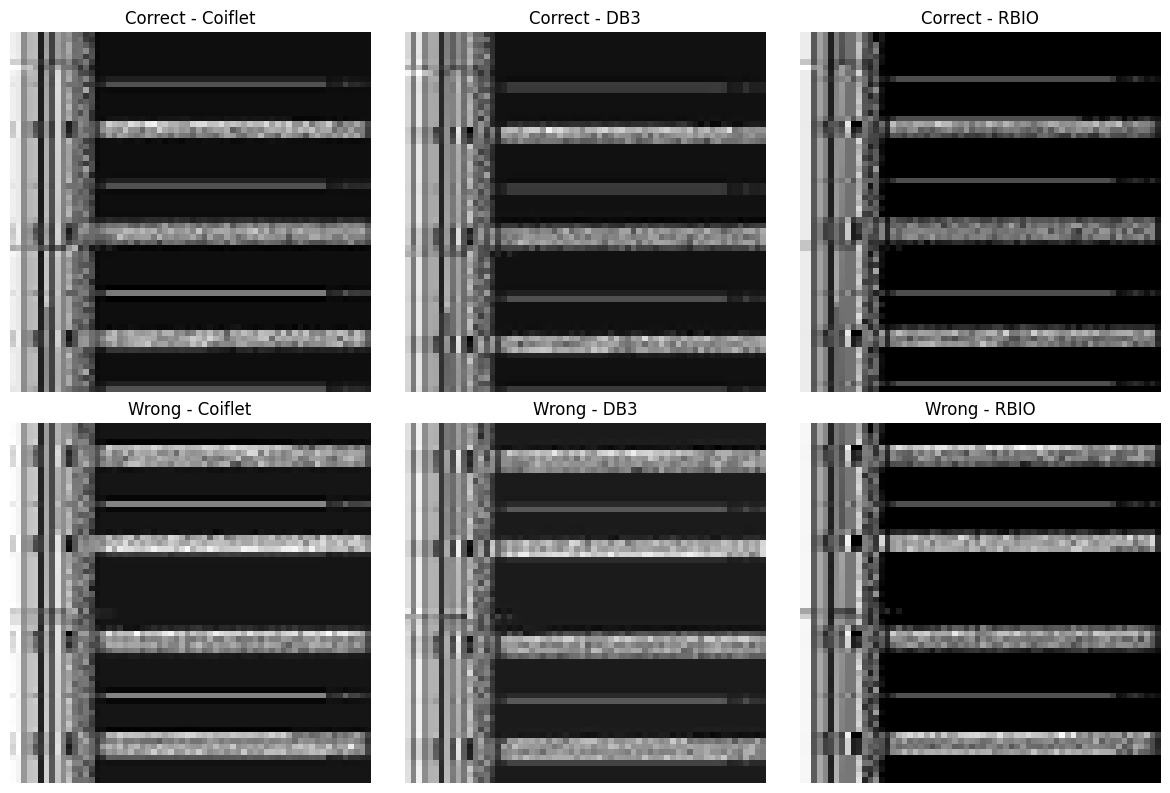

In [102]:
import matplotlib.pyplot as plt

correct = X_test[1453]
wrong   = X_test[1454]

titles = ["Coiflet", "DB3", "RBIO"]

fig, ax = plt.subplots(2,3, figsize=(12,8))

for i in range(3):

    ax[0,i].imshow(correct[:,:,i], cmap="gray")
    ax[0,i].set_title(f"Correct - {titles[i]}")
    ax[0,i].axis("off")

    ax[1,i].imshow(wrong[:,:,i], cmap="gray")
    ax[1,i].set_title(f"Wrong - {titles[i]}")
    ax[1,i].axis("off")

plt.tight_layout()
plt.show()

In [103]:
import pandas as pd
import numpy as np

rows = []

for i,name in enumerate(titles):

    rows.append({
        "Wavelet": name,
        "Image":"Correct",
        "Mean":correct[:,:,i].mean(),
        "Std":correct[:,:,i].std(),
        "Min":correct[:,:,i].min(),
        "Max":correct[:,:,i].max(),
        "Energy":np.sum(correct[:,:,i]**2)
    })

    rows.append({
        "Wavelet": name,
        "Image":"Wrong",
        "Mean":wrong[:,:,i].mean(),
        "Std":wrong[:,:,i].std(),
        "Min":wrong[:,:,i].min(),
        "Max":wrong[:,:,i].max(),
        "Energy":np.sum(wrong[:,:,i]**2)
    })

pd.DataFrame(rows)

,Wavelet,Image,Mean,Std,Min,Max,Energy
0,Coiflet,Correct,0.599351,0.833790,-0.179817,3.000933,4318.935547
1,Coiflet,Wrong,0.686292,0.883412,-0.259848,2.846687,5125.791016
2,DB3,Correct,0.607611,0.817305,-0.239461,3.188421,4248.282715
3,DB3,Wrong,0.698738,0.860115,-0.373931,3.063250,5030.024414
4,RBIO,Correct,0.592763,0.822769,0.000000,3.270588,4211.987793
5,RBIO,Wrong,0.681118,0.890310,0.000000,3.126470,5146.923828


In [104]:
titles = ["Coiflet","DB3","RBIO"]

for i,name in enumerate(titles):

    diff = np.abs(correct[:,:,i]-wrong[:,:,i])

    print("="*40)
    print(name)

    print("Mean Difference :", diff.mean())
    print("Max Difference  :", diff.max())
    print("Std Difference  :", diff.std())

Coiflet
Mean Difference : 0.5914525
Max Difference  : 2.8264763
Std Difference  : 0.7131106
DB3
Mean Difference : 0.58383024
Max Difference  : 3.0260768
Std Difference  : 0.703278
RBIO
Mean Difference : 0.5721469
Max Difference  : 3.1264703
Std Difference  : 0.7076247


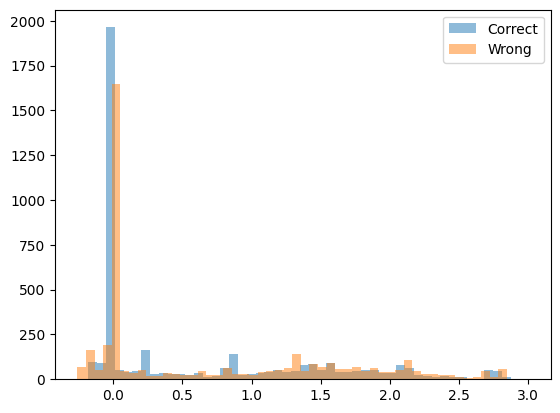

In [105]:
plt.hist(correct[:,:,0].flatten(), bins=50, alpha=0.5, label="Correct")
plt.hist(wrong[:,:,0].flatten(), bins=50, alpha=0.5, label="Wrong")
plt.legend()

In [107]:
normal_window = np.where(y_test == 0)[0][0]
print(normal_window)

0


In [108]:
normal  = X_test[normal_window][:,:,0]
correct = X_test[1161][:,:,0]
wrong   = X_test[1454][:,:,0]

print("Normal-Correct :", np.mean(np.abs(normal-correct)))
print("Normal-Wrong   :", np.mean(np.abs(normal-wrong)))
print("Correct-Wrong  :", np.mean(np.abs(correct-wrong)))

Normal-Correct : 1.3503788
Normal-Wrong   : 1.3731232
Correct-Wrong  : 0.5267909


In [110]:
normal_mean = X_test[y_test == 0][:,:, :, 0].mean(axis=0)

correct = X_test[1161][:,:,0]
wrong   = X_test[1454][:,:,0]

print("MeanNormal-Correct :", np.mean(np.abs(normal_mean-correct)))
print("MeanNormal-Wrong   :", np.mean(np.abs(normal_mean-wrong)))
print("Correct-Wrong      :", np.mean(np.abs(correct-wrong)))

MeanNormal-Correct : 0.58912027
MeanNormal-Wrong   : 0.58360744
Correct-Wrong      : 0.5267909


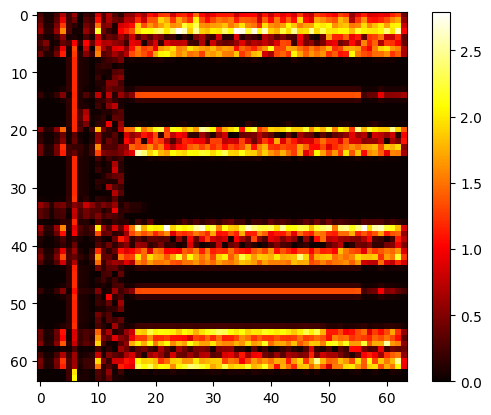

In [111]:
diff = np.abs(correct - wrong)

plt.imshow(diff, cmap="hot")
plt.colorbar()

In [112]:
for i, name in enumerate(["Coiflet", "DB3", "RBIO"]):
    diff = np.abs(X_test[1161][:,:,i] - X_test[1454][:,:,i])

    changed = np.sum(diff > 0.5)
    total = diff.size

    print(name)
    print("Changed Pixels :", changed)
    print("Percentage     :", changed/total*100)

Coiflet
Changed Pixels : 1385
Percentage     : 33.8134765625
DB3
Changed Pixels : 1511
Percentage     : 36.8896484375
RBIO
Changed Pixels : 1515
Percentage     : 36.9873046875
